## Columns Description
ID: Unique identifier for each borrower.

Age: Age of the borrower.

Gender: Gender of the borrower.

Income: Monthly or annual income of the borrower.

Employment Status: Employment status (e.g., employed, self-employed, unemployed).

Credit Score: Credit score of the borrower.

Loan Amount: Amount of the loan applied for or granted.

Loan Purpose: Purpose of the loan (e.g., personal, education, mortgage).

Loan Term: Term of the loan in months or years.

Interest Rate: Interest rate applied to the loan.

Number of Dependents: Number of dependents the borrower has.

Marital Status: Marital status of the borrower.

Education Level: Highest education level attained by the borrower.

Residential Status: Type of residence (e.g., owned, rented).

Existing Loans: Number and amount of existing loans.

Credit History Length: Duration of the borrower’s credit history.

Default Status: Target variable indicating whether the borrower defaulted (1) or not (0).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import phik as phik

In [2]:
# Constants
RANDOM_STATE = 42
PATH_TO_DATA = '../data/train-FIN_ANA_DATA.xls'

In [3]:
df = pd.read_excel(PATH_TO_DATA)
df.head()

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37408 entries, 0 to 37407
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ACC_NO                37408 non-null  int64  
 1   INVESTMENT_TOTAL      37408 non-null  int64  
 2   ACCCURRENTBALANCE     37408 non-null  int64  
 3   INF_MARITAL_STATUS    37406 non-null  str    
 4   INF_GENDER            37406 non-null  str    
 5   INSTALL_SIZE          36570 non-null  float64
 6   DUE_PAYMENT           37408 non-null  int64  
 7   COMPENSATION_CHARGED  37406 non-null  str    
 8   CLIENT_TYPE           37305 non-null  object 
 9   QUALITY_OF_LOAN       37408 non-null  str    
 10  REPAY_MODE            37408 non-null  str    
dtypes: float64(1), int64(4), object(1), str(5)
memory usage: 3.1+ MB


In [5]:
df.describe()

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INSTALL_SIZE,DUE_PAYMENT
count,3.740800e+04,3.740800e+04,3.740800e+04,3.657000e+04,3.740800e+04
mean,5.765462e+11,6.204059e+06,1.174438e+06,4.569050e+04,3.758206e+05
std,4.512335e+11,2.608868e+07,6.229215e+06,6.634519e+05,4.406148e+06
min,2.701002e+10,5.001500e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.978200e+11,8.367750e+05,2.178000e+03,0.000000e+00,0.000000e+00
50%,4.380700e+11,1.634892e+06,2.448400e+04,0.000000e+00,0.000000e+00
75%,8.983500e+11,4.365000e+06,3.416390e+05,0.000000e+00,0.000000e+00
max,1.598350e+12,1.509387e+09,2.174153e+08,5.984437e+07,3.701924e+08


In [6]:
print('N/A check\n')
df.isna().sum()

N/A check



ACC_NO                    0
INVESTMENT_TOTAL          0
ACCCURRENTBALANCE         0
INF_MARITAL_STATUS        2
INF_GENDER                2
INSTALL_SIZE            838
DUE_PAYMENT               0
COMPENSATION_CHARGED      2
CLIENT_TYPE             103
QUALITY_OF_LOAN           0
REPAY_MODE                0
dtype: int64

In [7]:
print(f"Full duplicates: {int(df.duplicated().sum())}")
print(f"Account № duplicates: {int(df.duplicated(subset='ACC_NO').sum())}")


Full duplicates: 0
Account № duplicates: 0


In [8]:
print('Number of unique values in each columns:\n')
for col in df:
    print(f"{col} : {df[col].nunique()}")

Number of unique values in each columns:

ACC_NO : 37408
INVESTMENT_TOTAL : 18465
ACCCURRENTBALANCE : 5920
INF_MARITAL_STATUS : 3
INF_GENDER : 3
INSTALL_SIZE : 4535
DUE_PAYMENT : 4738
COMPENSATION_CHARGED : 2
CLIENT_TYPE : 4
QUALITY_OF_LOAN : 2
REPAY_MODE : 2


In [9]:
for col in ['INF_MARITAL_STATUS', 'INF_GENDER', 'COMPENSATION_CHARGED', 'CLIENT_TYPE', 'QUALITY_OF_LOAN', 'REPAY_MODE']:
    print(f"{col} : {df[col].unique()}")
    print()

INF_MARITAL_STATUS : <StringArray>
['M', 'U', 'O', nan]
Length: 4, dtype: str

INF_GENDER : <StringArray>
['F', 'M', nan, 'O']
Length: 4, dtype: str

COMPENSATION_CHARGED : <StringArray>
['N', 'Y', nan]
Length: 3, dtype: str

CLIENT_TYPE : ['Semi-urban' 'Rural' 'Urban' nan 0]

QUALITY_OF_LOAN : <StringArray>
['G', 'B']
Length: 2, dtype: str

REPAY_MODE : <StringArray>
['N', 'I']
Length: 2, dtype: str



Categorical columns are:
- INF_MARITAL_STATUS
- INF_GENDER
- COMPENSATION_CHARGED
- CLIENT_TYPE
- QUALITY_OF_LOAN
- REPAY_MODE


Numeric columns are:
- INVESTMENT_TOTAL
- ACCCURRENTBALANCE
- INSTALL_SIZE
- DUE_PAYMENT

## EDA

In [10]:
# Outliers analysis
for col in ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
          'INSTALL_SIZE', 'DUE_PAYMENT']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].to_list()
    print(f"Column {col}:")
    print(f"Mean: {df[col].mean():.0f}; Median: {df[col].median():.0f}; Max: {df[col].max():.0f}; Min: {df[col].min():.0f}")
    print(f"Outliers: {len(outliers) if outliers else 'No outliers'}")
    print()

Column INVESTMENT_TOTAL:
Mean: 6204059; Median: 1634892; Max: 1509387375; Min: 500150
Outliers: 4680

Column ACCCURRENTBALANCE:
Mean: 1174438; Median: 24484; Max: 217415344; Min: 0
Outliers: 6636

Column INSTALL_SIZE:
Mean: 45690; Median: 0; Max: 59844373; Min: 0
Outliers: 6142

Column DUE_PAYMENT:
Mean: 375821; Median: 0; Max: 370192428; Min: 0
Outliers: 5991



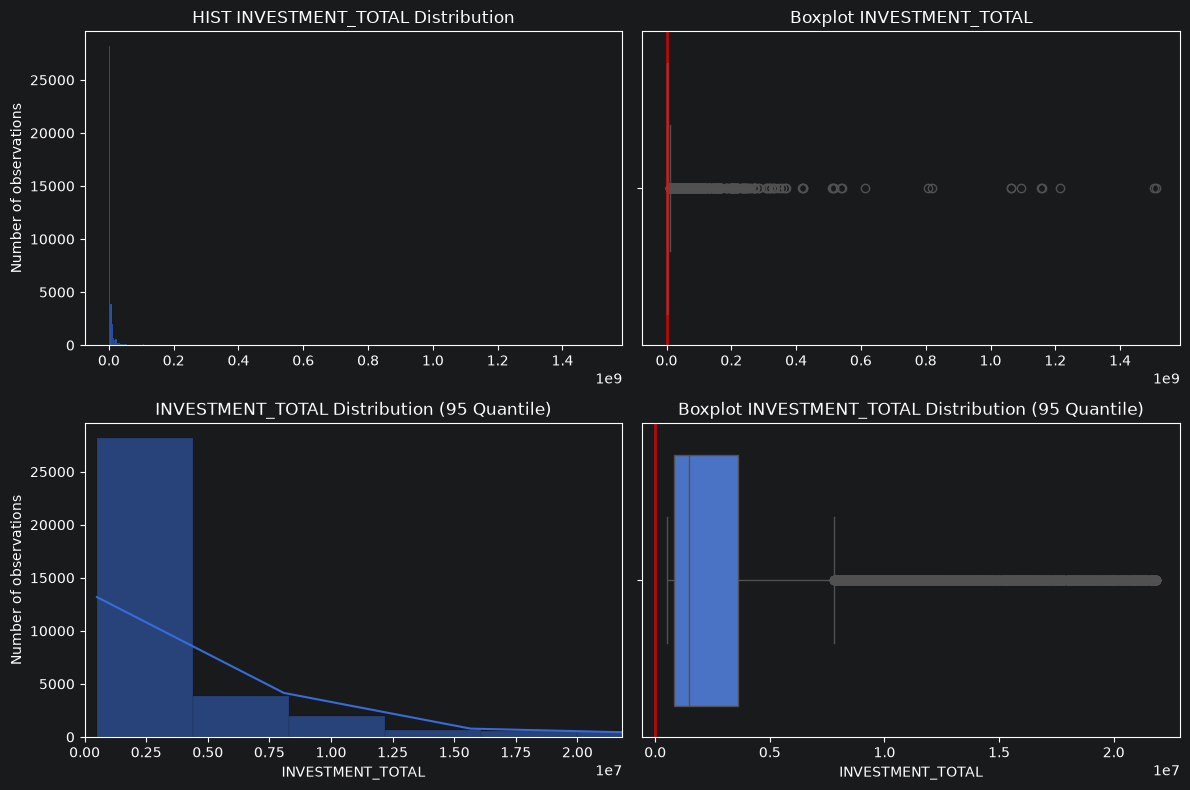

In [82]:
# INVESTMENT_TOTAL
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(ax1, ax2, ax3, ax4) = axes.flatten()

sns.histplot(data=df, x='INVESTMENT_TOTAL', ax=ax1)
ax1.set_title('HIST INVESTMENT_TOTAL Distribution')
ax1.set_xlabel('')
ax1.set_ylabel('Number of observations')


sns.boxplot(data=df, x='INVESTMENT_TOTAL', ax=ax2)
ax2.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax2.set_title('Boxplot INVESTMENT_TOTAL')
ax2.set_xlabel('')


sns.histplot(data=df, x='INVESTMENT_TOTAL',
             kde=True, ax=ax3)
ax3.set_title('INVESTMENT_TOTAL Distribution (95 Quantile)')
ax3.set_xlabel('INVESTMENT_TOTAL')
ax3.set_ylabel('Number of observations')
ax3.set_xlim(0, df['INVESTMENT_TOTAL'].quantile(0.95))

sns.boxplot(data=df[df['INVESTMENT_TOTAL']<= df['INVESTMENT_TOTAL'].quantile(0.95)], x='INVESTMENT_TOTAL', ax=ax4)
ax4.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax4.set_title('Boxplot INVESTMENT_TOTAL Distribution (95 Quantile)')

plt.tight_layout()
plt.show()



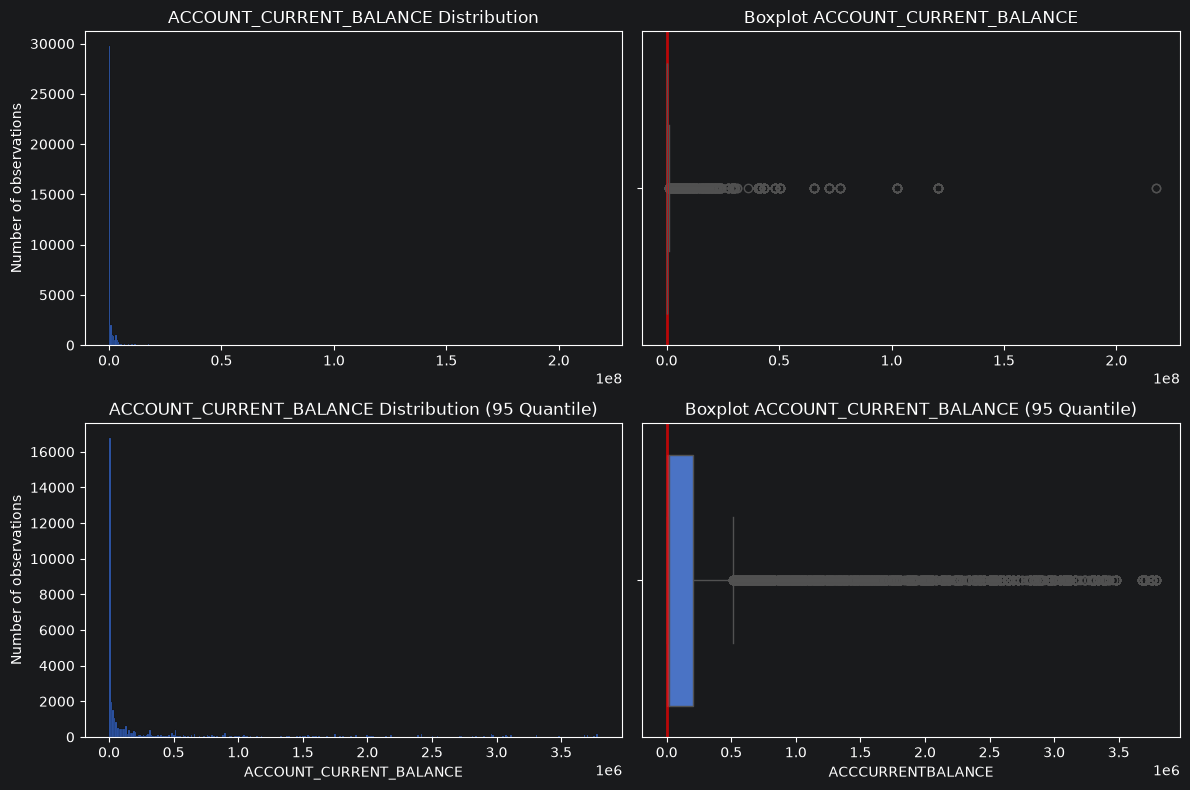

In [96]:
# ACCCURRENTBALANCE

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(ax1, ax2, ax3, ax4) = axes.flatten()


sns.histplot(data=df, x='ACCCURRENTBALANCE', ax=ax1)
ax1.set_title('ACCOUNT_CURRENT_BALANCE Distribution')
ax1.set_xlabel('')
ax1.set_ylabel('Number of observations')

sns.boxplot(data=df, x='ACCCURRENTBALANCE', ax=ax2)
ax2.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_title('Boxplot ACCOUNT_CURRENT_BALANCE')

sns.histplot(data=df[df['ACCCURRENTBALANCE']<=df['ACCCURRENTBALANCE']
            .quantile(0.95)], x='ACCCURRENTBALANCE', ax=ax3)
ax3.set_title('ACCOUNT_CURRENT_BALANCE Distribution (95 Quantile)')
ax3.set_xlabel('ACCOUNT_CURRENT_BALANCE')
ax3.set_ylabel('Number of observations')

sns.boxplot(data=df[df['ACCCURRENTBALANCE']<=df['ACCCURRENTBALANCE']
            .quantile(0.95)], x='ACCCURRENTBALANCE', ax=ax4)
ax4.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax4.set_title('Boxplot ACCOUNT_CURRENT_BALANCE (95 Quantile)')


plt.tight_layout()
plt.show()

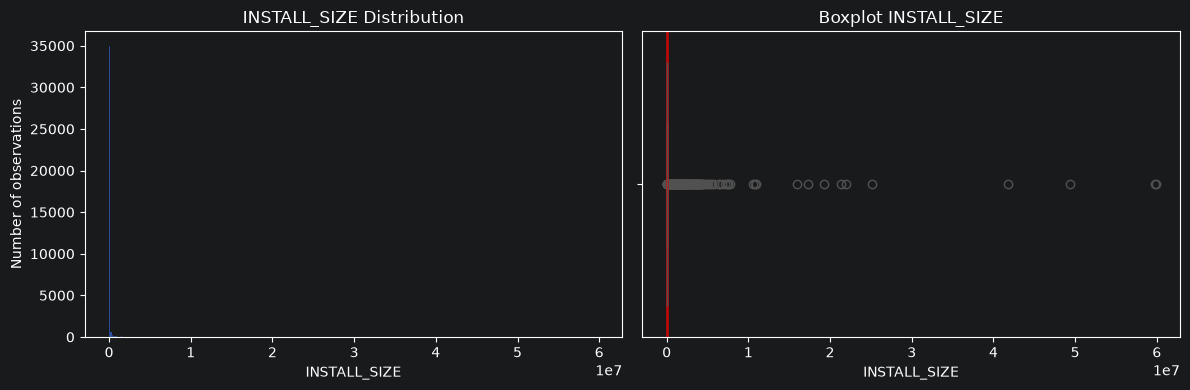

In [107]:
# INSTALL_SIZE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(ax1, ax2) = axes.flatten()

sns.histplot(data=df, x='INSTALL_SIZE', ax=ax1)
ax1.set_title('INSTALL_SIZE Distribution')
ax1.set_xlabel('INSTALL_SIZE')
ax1.set_ylabel('Number of observations')

sns.boxplot(data=df, x='INSTALL_SIZE', ax=ax2)
ax2.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax2.set_xlabel('INSTALL_SIZE')
ax2.set_ylabel('')
ax2.set_title('Boxplot INSTALL_SIZE')

plt.tight_layout()
plt.show()

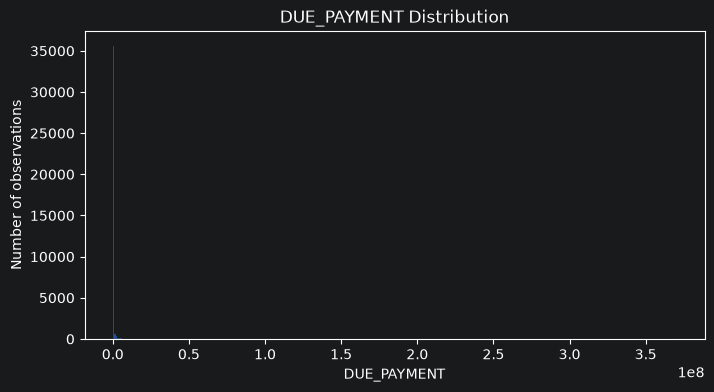

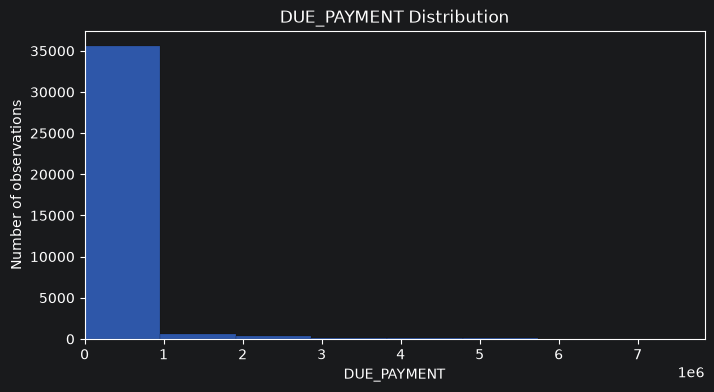

In [14]:
# DUE_PAYMENT

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='DUE_PAYMENT')
plt.title('DUE_PAYMENT Distribution')
plt.xlabel('DUE_PAYMENT')
plt.ylabel('Number of observations')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='DUE_PAYMENT')
plt.title('DUE_PAYMENT Distribution')
plt.xlabel('DUE_PAYMENT')
plt.ylabel('Number of observations')
plt.xlim(0, df['DUE_PAYMENT'].quantile(0.99))
plt.show()

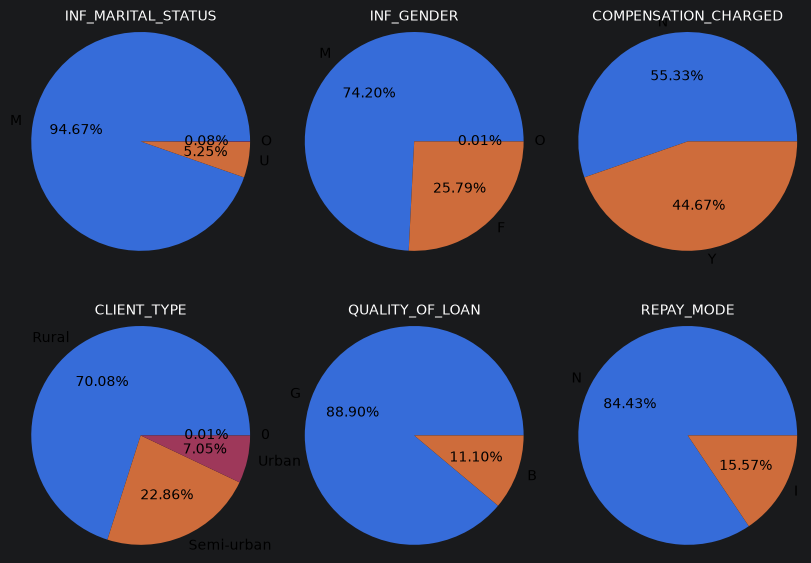

In [63]:
inf_material = df['INF_MARITAL_STATUS'].value_counts()
inf_gender = df['INF_GENDER'].value_counts()
compensation_charged = df['COMPENSATION_CHARGED'].value_counts()
client_type = df['CLIENT_TYPE'].value_counts()
quality_of_loan = df['QUALITY_OF_LOAN'].value_counts()
repay_mode = df['REPAY_MODE'].value_counts()


fig, axes = plt.subplots(2, 3, figsize=(10, 7))
(ax1, ax2, ax3, ax4, ax5, ax6) = axes.flatten()

# INF_MARITAL_STATUS
ax1.pie(inf_material,
       labels=inf_material.index,
       radius=1.2,
       autopct='%.2f%%',
       textprops=dict(color='black', fontsize=10))
ax1.set_title('INF_MARITAL_STATUS', pad=5, fontsize=10)

# INF_GENDER
ax2.pie(inf_gender,
       labels=inf_gender.index,
       radius=1.2,
       autopct='%.2f%%',
       textprops=dict(color='black', fontsize=10))
ax2.set_title('INF_GENDER', pad=5, fontsize=10)

# COMPENSATION_CHARGED
ax3.pie(compensation_charged,
        labels=compensation_charged.index,
        radius=1.2,
        autopct='%.2f%%',
        textprops=dict(color='black', fontsize=10))
ax3.set_title('COMPENSATION_CHARGED', pad=5, fontsize=10)

# CLIENT_TYPE
ax4.pie(client_type,
        labels=client_type.index,
        radius=1.2,
        autopct='%.2f%%',
        textprops=dict(color='black', fontsize=10))
ax4.set_title('CLIENT_TYPE', pad=5, fontsize=10)

# QUALITY_OF_LOAN
ax5.pie(quality_of_loan,
        labels=quality_of_loan.index,
        radius=1.2,
        autopct='%.2f%%',
        textprops=dict(color='black', fontsize=10))
ax5.set_title('QUALITY_OF_LOAN', pad=5, fontsize=10)

# REPAY_MODE
ax6.pie(repay_mode,
        labels=repay_mode.index,
        radius=1.2,
        autopct='%.2f%%',
        textprops=dict(color='black', fontsize=10))
ax6.set_title('REPAY_MODE', pad=5, fontsize=10)

plt.show()